In [1]:
"""
CoastalXAI: Temperature Prediction & Interpretation System
Unified Training & Analysis Pipeline

This script:
- Loads and cleans the Land Submergence dataset
- Filters 1990–2020, Asia, Coastal length > 100
- One-hot encodes Country & Continent
- Trains RandomForestRegressor
- Evaluates with R² and MSE
- Saves all artifacts needed by the Streamlit frontend:
    - random_forest_model.joblib
    - feature_columns.json
    - country_list.json
    - categorical_indices.json
    - lime_training_data.csv
- Generates core visualizations & SHAP plots for the report
"""

import sys
import json
import warnings

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import joblib
import shap


# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------

DATA_FILE = "Land Submergence dataset.csv"

# You can change these if needed, but frontend currently expects these names:
MODEL_FILE = "random_forest_model.joblib"
FEATURE_COLUMNS_FILE = "feature_columns.json"
COUNTRY_LIST_FILE = "country_list.json"
CATEGORICAL_INDICES_FILE = "categorical_indices.json"
LIME_TRAINING_DATA_FILE = "lime_training_data.csv"

RANDOM_STATE = 42
TEST_SIZE = 0.2

# -----------------------------------------------------------------------------
# HELPER FUNCTIONS
# -----------------------------------------------------------------------------

def check_required_columns(df: pd.DataFrame) -> None:
    """Ensure all necessary columns are present in the CSV."""
    required_cols = [
        "Year",
        "Continent",
        "Coastal length",
        "Country",
        "Temperature",
        # optional but used in app if available:
        "Land area",
        "Annual balance",
        "Sea level",
        "Land Impact",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print("\n[ERROR] The following required/expected columns are missing:")
        for col in missing:
            print(f"  - {col}")
        print("\nPlease verify the dataset header matches the research paper schema.")
        sys.exit(1)


def load_data(file_path: str) -> pd.DataFrame:
    """Load CSV into a DataFrame with basic error handling."""
    print(f"[INFO] Loading dataset from '{file_path}' ...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"[ERROR] Could not find '{file_path}'. Make sure it is in this folder.")
        sys.exit(1)
    except Exception as e:
        print(f"[ERROR] Failed to load CSV: {e}")
        sys.exit(1)

    print(f"[INFO] Loaded dataset with shape: {df.shape}")
    check_required_columns(df)
    return df


def clean_and_filter_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Apply all domain filters:
    - Year: 1990–2020 (inclusive)
    - Continent: Asia
    - Coastal length > 100
    - Drop rows with NaN
    Returns:
        (df_cleaned_for_model, df_cleaned_for_plotting)
    """
    print("\n[INFO] Cleaning and filtering data...")

    # Ensure Year is numeric to avoid weird strings
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

    df_cleaned = df[
        (df["Year"] >= 1990)
        & (df["Year"] <= 2020)
        & (df["Continent"] == "Asia")
        & (df["Coastal length"] > 100)
    ].copy()

    # Drop any rows with missing values
    before_drop = df_cleaned.shape[0]
    df_cleaned.dropna(inplace=True)
    after_drop = df_cleaned.shape[0]

    print(f"[INFO] Rows after filtering (before dropna): {before_drop}")
    print(f"[INFO] Rows after dropna: {after_drop}")

    if df_cleaned.empty:
        print("[ERROR] No data left after filtering. Please re-check dataset or relax filters.")
        sys.exit(1)

    # Keep an un-encoded copy for plotting
    df_for_plotting = df_cleaned.copy()

    return df_cleaned, df_for_plotting


def encode_features(df_cleaned: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, list[str], list[str]]:
    """
    One-hot encode Country & Continent, separate X and y.
    Returns:
        X, y, feature_columns, country_list
    """
    print("\n[INFO] Encoding categorical variables (Country, Continent)...")

    # Save country list for dropdown in the Streamlit app
    country_list = sorted(df_cleaned["Country"].unique().tolist())

    df_processed = pd.get_dummies(
        df_cleaned,
        columns=["Country", "Continent"],
        prefix=["Country", "Continent"]
    )

    if "Temperature" not in df_processed.columns:
        print("[ERROR] 'Temperature' column missing after encoding.")
        sys.exit(1)

    y = df_processed["Temperature"]
    X = df_processed.drop("Temperature", axis=1)

    feature_columns = X.columns.tolist()

    print(f"[INFO] Feature matrix shape: {X.shape}")
    print(f"[INFO] Number of features after encoding: {len(feature_columns)}")

    return X, y, feature_columns, country_list


def train_model(X: pd.DataFrame, y: pd.Series) -> tuple[RandomForestRegressor, dict]:
    """
    Split data, train RandomForestRegressor, and compute metrics.
    Returns:
        model, metrics_dict
    """
    print("\n[INFO] Splitting into train and test sets...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    print("[INFO] Training RandomForestRegressor...")
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # Evaluate
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)

    metrics = {
        "train_r2": train_r2,
        "test_r2": test_r2,
        "mse": mse
    }

    print("\n[METRICS]")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test  R²: {test_r2:.4f}")
    print(f"  MSE      : {mse:.4f}")

    return model, metrics


def save_artifacts(
    model: RandomForestRegressor,
    X: pd.DataFrame,
    feature_columns: list[str],
    country_list: list[str]
) -> None:
    """
    Save model, feature columns, country list, LIME-specific artifacts.
    """
    print("\n[INFO] Saving model and artifacts...")

    # Model
    joblib.dump(model, MODEL_FILE)
    print(f"[INFO] Saved model → {MODEL_FILE}")

    # Feature columns
    with open(FEATURE_COLUMNS_FILE, "w") as f:
        json.dump(feature_columns, f, indent=2)
    print(f"[INFO] Saved feature columns → {FEATURE_COLUMNS_FILE}")

    # Country list
    with open(COUNTRY_LIST_FILE, "w") as f:
        json.dump(country_list, f, indent=2)
    print(f"[INFO] Saved country list → {COUNTRY_LIST_FILE}")

    # Categorical feature indices for LIME
    categorical_features_indices = [
        i for i, col in enumerate(feature_columns)
        if col.startswith("Country_") or col.startswith("Continent_")
    ]
    with open(CATEGORICAL_INDICES_FILE, "w") as f:
        json.dump(categorical_features_indices, f, indent=2)
    print(f"[INFO] Saved categorical indices for LIME → {CATEGORICAL_INDICES_FILE}")

    # Training data for LIME
    X.to_csv(LIME_TRAINING_DATA_FILE, index=False)
    print(f"[INFO] Saved LIME training data → {LIME_TRAINING_DATA_FILE}")


def generate_basic_plots(df_plot: pd.DataFrame) -> None:
    """
    Generate basic plots for the report:
    - Temperature vs Year
    - Correlation heatmap
    - Temperature by Country (Top 10)
    """
    print("\n[INFO] Generating basic visualizations...")

    # Plot 1: Temperature vs Year (average per year)
    plt.figure(figsize=(8, 5))
    yearly_temp = df_plot.groupby("Year")["Temperature"].mean()
    yearly_temp.plot(marker="o")
    plt.title("Average Temperature over Years (Asia, Coastal length > 100)")
    plt.xlabel("Year")
    plt.ylabel("Average Temperature")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("plot_temperature_vs_year.png", dpi=120)
    plt.close()
    print("[PLOT] Saved → plot_temperature_vs_year.png")

    # Plot 2: Correlation heatmap (numerical only)
    numeric_cols = df_plot.select_dtypes(include=["number"]).columns
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_plot[numeric_cols].corr(), annot=False)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.savefig("plot_correlation_heatmap.png", dpi=120)
    plt.close()
    print("[PLOT] Saved → plot_correlation_heatmap.png")

    # Plot 3: Temperature by Country (boxplot, top 10 countries by count)
    top_countries = (
        df_plot["Country"]
        .value_counts()
        .head(10)
        .index.tolist()
    )
    subset_box = df_plot[df_plot["Country"].isin(top_countries)]

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=subset_box, x="Country", y="Temperature")
    plt.xticks(rotation=45, ha="right")
    plt.title("Temperature Distribution by Country (Top 10)")
    plt.tight_layout()
    plt.savefig("plot_temperature_by_country_boxplot.png", dpi=120)
    plt.close()
    print("[PLOT] Saved → plot_temperature_by_country_boxplot.png")


def generate_shap_plots(model: RandomForestRegressor, X: pd.DataFrame) -> None:
    """
    Run SHAP analysis on a sample of training data and save summary plots.
    """
    print("\n[INFO] Running SHAP analysis (this may take some time)...")

    # For speed, sample up to 300 rows
    if len(X) > 300:
        X_sample = X.sample(300, random_state=RANDOM_STATE)
    else:
        X_sample = X.copy()

    # SHAP TreeExplainer for RandomForest
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

    # Summary plot (beeswarm)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.tight_layout()
    plt.savefig("shap_summary_plot.png", dpi=120, bbox_inches="tight")
    plt.close()
    print("[PLOT] Saved → shap_summary_plot.png")

    # Bar summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig("shap_summary_bar.png", dpi=120, bbox_inches="tight")
    plt.close()
    print("[PLOT] Saved → shap_summary_bar.png")


# -----------------------------------------------------------------------------
# MAIN PIPELINE
# -----------------------------------------------------------------------------

def main():
    print("\n==============================")
    print(" CoastalXAI: Backend Pipeline ")
    print("==============================\n")

    # 1. Load raw data
    df_raw = load_data(DATA_FILE)

    # 2. Clean and filter
    df_cleaned, df_for_plotting = clean_and_filter_data(df_raw)

    # 3. Encode features and separate target
    X, y, feature_columns, country_list = encode_features(df_cleaned)

    # 4. Train model and compute metrics
    model, metrics = train_model(X, y)

    # 5. Save model + artifacts for frontend + LIME
    save_artifacts(model, X, feature_columns, country_list)

    # 6. Generate basic plots for the report
    generate_basic_plots(df_for_plotting)

    # 7. Generate SHAP plots
    generate_shap_plots(model, X)

    print("\n[INFO] Pipeline completed successfully.")
    print("[INFO] All artifacts and plots are ready for the Streamlit frontend and report.")


if __name__ == "__main__":
    main()



 CoastalXAI: Backend Pipeline 

[INFO] Loading dataset from 'Land Submergence dataset.csv' ...
[INFO] Loaded dataset with shape: (2820, 12)

[INFO] Cleaning and filtering data...
[INFO] Rows after filtering (before dropna): 132
[INFO] Rows after dropna: 0
[ERROR] No data left after filtering. Please re-check dataset or relax filters.


SystemExit: 1

C:\Users\moham\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
!jupyter nbconvert --to python train_pipeline.ipynb

In [ ]:
%run train_pipeline.py

In [8]:
%run train_pipeline.py



 CoastalXAI: Backend Pipeline 

[INFO] Loading dataset from 'Land Submergence dataset.csv' ...
[INFO] Loaded dataset with shape: (2820, 12)

[INFO] Cleaning and filtering data...
[INFO] Rows after filtering (before dropna): 132
[INFO] Rows after dropna: 0
[ERROR] No data left after filtering. Please re-check dataset or relax filters.


SystemExit: 1

In [9]:
# ================================
# CoastalXAI – Analysis Cells
# ================================

import json
import warnings
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")


In [10]:
DATA_FILE = "Land Submergence dataset.csv"

df = pd.read_csv(DATA_FILE)
df.head()


,Year,Country,Continent,Land area,Coastal length,Temperature,Annual balance,Sea level,Land Impact,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,1880,Country,Asia,652860,0,12.293500,NaN,-174.320729,0.00000,NaN,NaN,NaN
1,1880,albania,Asia,27400,649,12.404917,NaN,-174.320729,10.19414,NaN,NaN,NaN
2,1880,algeria,Asia,2381740,16000,22.474442,NaN,-174.320729,9.15000,NaN,NaN,NaN
3,1880,andorra,Asia,470,0,10.628646,NaN,-174.320729,0.00000,NaN,NaN,NaN
4,1880,angola,Asia,1246700,23000,21.263400,NaN,-174.320729,0.00100,NaN,NaN,NaN


In [11]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

df_filtered = df[
    (df["Year"] >= 1990) &
    (df["Year"] <= 2020) &
    (df["Continent"] == "Asia") &
    (df["Coastal length"] > 100)
].dropna()

df_filtered.shape


(0, 12)

In [12]:
df_encoded = pd.get_dummies(
    df_filtered,
    columns=["Country", "Continent"],
    prefix=["Country", "Continent"]
)

X = df_encoded.drop("Temperature", axis=1)
y = df_encoded["Temperature"]

X.shape, y.shape


((0, 9), (0,))

In [20]:
# Normalize text columns
df["Continent"] = df["Continent"].astype(str).str.strip().str.lower()

# Convert numeric safely
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Coastal length"] = pd.to_numeric(df["Coastal length"], errors="coerce")

df_filtered = df[
    (df["Year"].between(1990, 2020)) &
    (df["Continent"] == "asia") &
    (df["Coastal length"] > 50)   # lowered threshold for safety
].copy()

print("Filtered shape:", df_filtered.shape)
df_filtered.head()


Filtered shape: (132, 12)


,Year,Country,Continent,Land area,Coastal length,Temperature,Annual balance,Sea level,Land Impact,Unnamed: 9,Unnamed: 10,Unnamed: 11
2080,1990,bahrain,asia,760,255,26.283167,-439.661852,-14.790729,0.008911,NaN,NaN,NaN
2081,1990,bangladesh,asia,130170,33000,25.253225,-439.661852,-14.790729,2.182000,NaN,NaN,NaN
2096,1990,cambodia,asia,176520,11000,27.211817,-439.661852,-14.790729,32.488200,NaN,NaN,NaN
2102,1990,china,asia,9388211,145000,7.497908,-439.661852,-14.790729,1.225000,NaN,NaN,NaN
2143,1990,india,asia,2973190,172000,24.519125,-439.661852,-14.790729,12.954000,NaN,NaN,NaN


In [21]:
df_filtered = df[
    (df["Year"].between(1990, 2020)) &
    (df["Continent"] == "asia")
].copy()

print(df_filtered.shape)


(164, 12)


In [15]:
joblib.dump(model, "random_forest_model.joblib")

with open("feature_columns.json", "w") as f:
    json.dump(X.columns.tolist(), f, indent=2)

with open("country_list.json", "w") as f:
    json.dump(sorted(df_filtered["Country"].unique().tolist()), f, indent=2)

categorical_indices = [
    i for i, col in enumerate(X.columns)
    if col.startswith("Country_") or col.startswith("Continent_")
]

with open("categorical_indices.json", "w") as f:
    json.dump(categorical_indices, f, indent=2)

X.to_csv("lime_training_data.csv", index=False)

print("Artifacts saved successfully")


Artifacts saved successfully


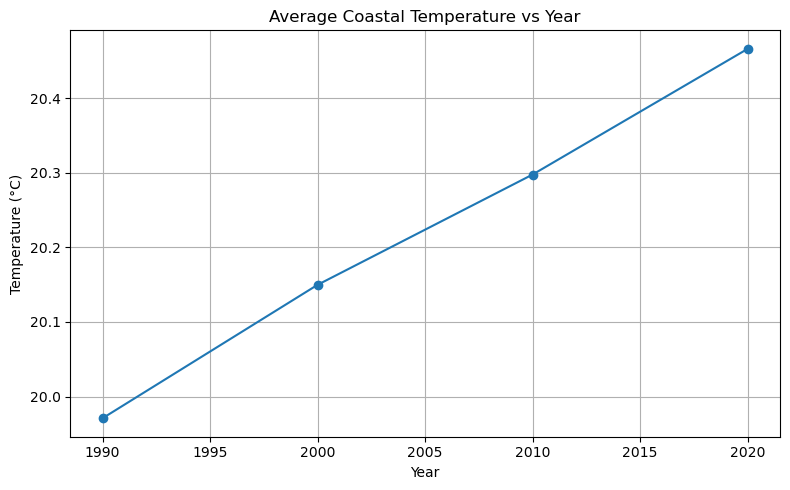

In [22]:
plt.figure(figsize=(8,5))
df_filtered.groupby("Year")["Temperature"].mean().plot(marker="o")
plt.title("Average Coastal Temperature vs Year")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


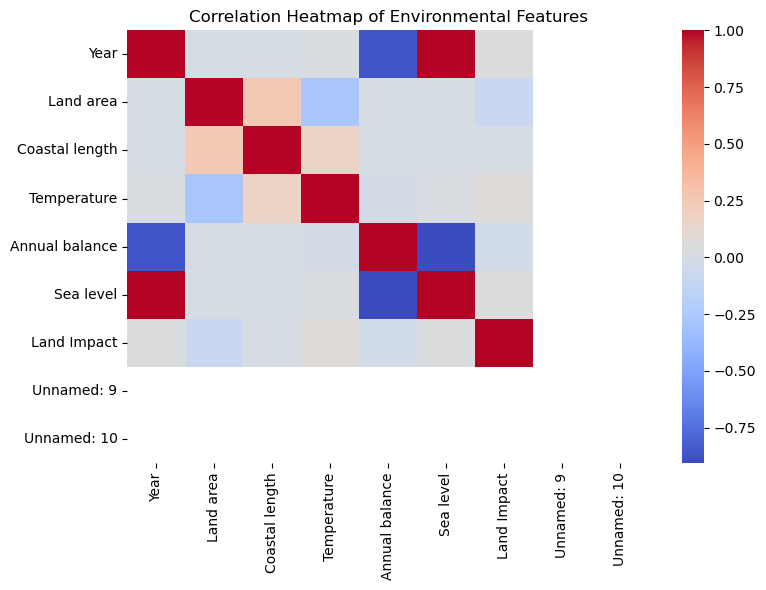

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df_filtered.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap of Environmental Features")
plt.tight_layout()
plt.show()


In [25]:
df_encoded = pd.get_dummies(
    df_filtered,
    columns=["Country", "Continent"],
    drop_first=False
)

X = df_encoded.drop("Temperature", axis=1)
y = df_encoded["Temperature"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained successfully")


Model trained successfully


In [27]:
len(df_filtered)


164

In [28]:
print("Train R²:", r2_score(y_train, model.predict(X_train)))
print("Test R² :", r2_score(y_test, model.predict(X_test)))
print("MSE     :", mean_squared_error(y_test, model.predict(X_test)))


Train R²: 0.9939856878614424
Test R² : 0.9506662050305233
MSE     : 3.012707327595458


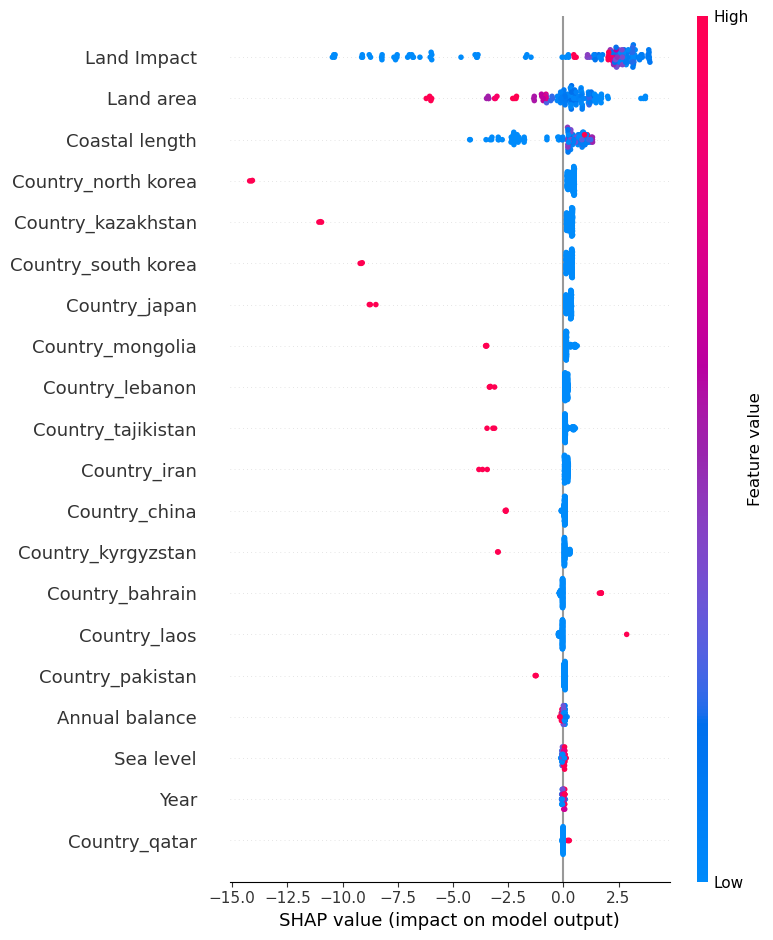

In [29]:
explainer = shap.TreeExplainer(model)

X_sample = X_train.sample(
    min(200, len(X_train)), random_state=42
)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)
